In [58]:
import pandas as pd
import matplotlib.pyplot as plt

acl_df = pd.read_csv("../data/processed/acl_analysis.csv")

In [59]:
acl_df["patient_id"].value_counts()

patient_id
P0031    12
P0040    12
P0049    12
P0026    10
P0088    10
         ..
P0075     1
P0081     1
P0083     1
P0084     1
P0096     1
Name: count, Length: 98, dtype: int64

In [60]:
visit_counts = acl_df["patient_id"].value_counts()

visit_counts.describe()

count    98.000000
mean      4.234694
std       3.089060
min       1.000000
25%       1.000000
50%       3.500000
75%       6.000000
max      12.000000
Name: count, dtype: float64

In [61]:
visit_counts.head(10)

patient_id
P0031    12
P0040    12
P0049    12
P0026    10
P0088    10
P0001     9
P0025     9
P0037     9
P0050     9
P0052     9
Name: count, dtype: int64

In [62]:
patient = acl_df[
    acl_df["patient_id"] == "P0031"
].sort_values("date_ami")

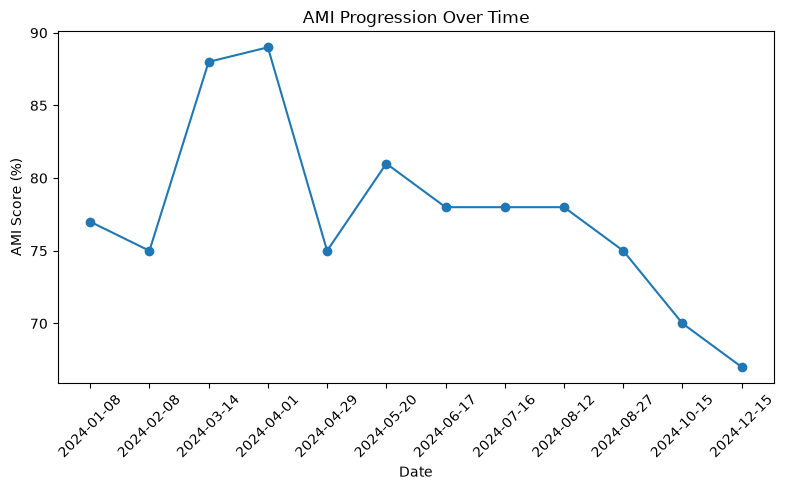

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    patient["date_ami"],
    patient["score_pct"],
    marker="o"
)

plt.title("AMI Progression Over Time")
plt.xlabel("Date")
plt.ylabel("AMI Score (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

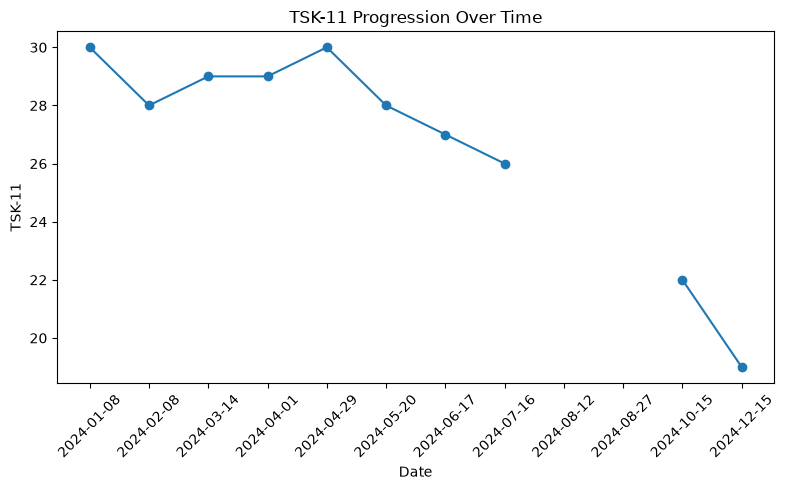

In [64]:
plt.figure(figsize=(8,5))

plt.plot(
    patient["date_ami"],
    patient["tsk_11"],
    marker="o"
)

plt.title("TSK-11 Progression Over Time")
plt.xlabel("Date")
plt.ylabel("TSK-11")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
patient["ami_scaled"] = (
    patient["score_pct"] -
    patient["score_pct"].mean()
) / patient["score_pct"].std()

patient["tsk_scaled"] = (
    patient["tsk_11"] -
    patient["tsk_11"].mean()
) / patient["tsk_11"].std()

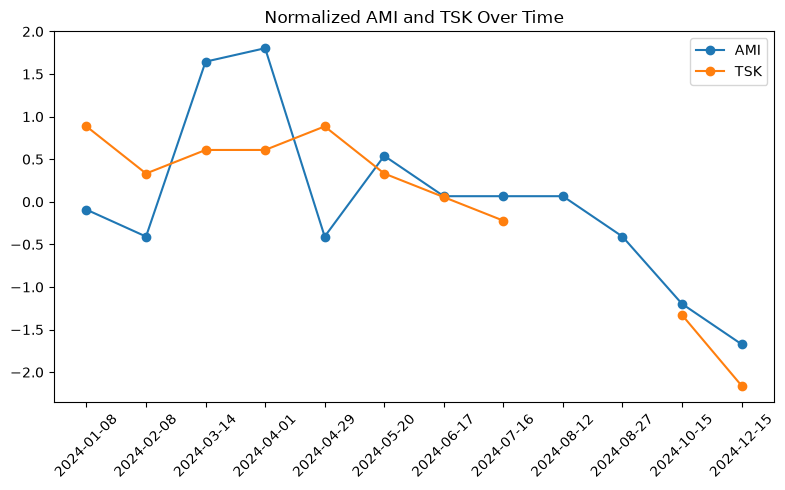

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    patient["date_ami"],
    patient["ami_scaled"],
    marker="o",
    label="AMI"
)

plt.plot(
    patient["date_ami"],
    patient["tsk_scaled"],
    marker="o",
    label="TSK"
)

plt.legend()
plt.title("Normalized AMI and TSK Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
patient2 = acl_df[
    acl_df["patient_id"] == "P0040"
].sort_values("date_ami")

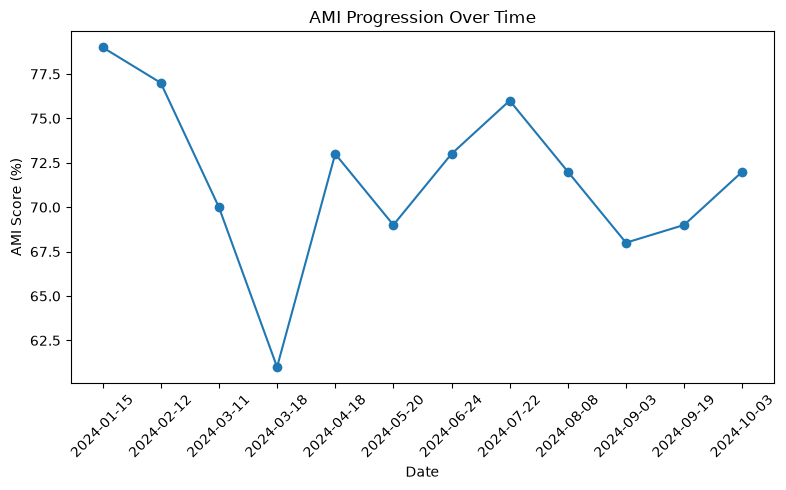

In [68]:
plt.figure(figsize=(8,5))

plt.plot(
    patient2["date_ami"],
    patient2["score_pct"],
    marker="o"
)

plt.title("AMI Progression Over Time")
plt.xlabel("Date")
plt.ylabel("AMI Score (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

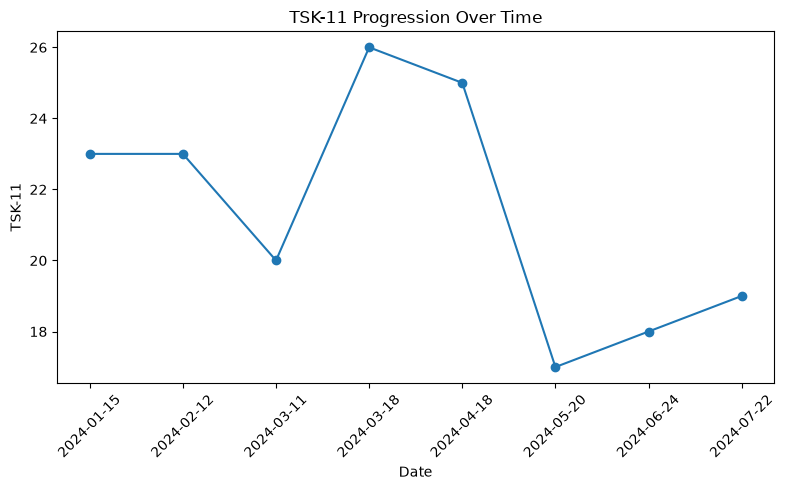

In [69]:
plt.figure(figsize=(8,5))

plt.plot(
    patient2["date_ami"],
    patient2["tsk_11"],
    marker="o"
)

plt.title("TSK-11 Progression Over Time")
plt.xlabel("Date")
plt.ylabel("TSK-11")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
patient2["ami_scaled"] = (
    patient2["score_pct"] -
    patient2["score_pct"].mean()
) / patient2["score_pct"].std()

patient2["tsk_scaled"] = (
    patient2["tsk_11"] -
    patient2["tsk_11"].mean()
) / patient2["tsk_11"].std()

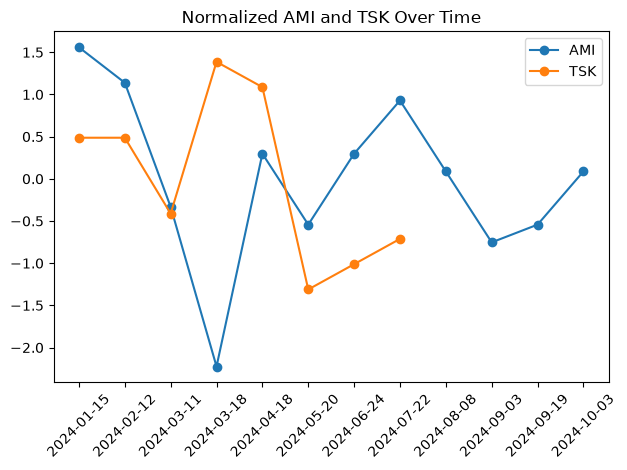

In [71]:
plt.plot(
    patient2["date_ami"],
    patient2["ami_scaled"],
    marker="o",
    label="AMI"
)

plt.plot(
    patient2["date_ami"],
    patient2["tsk_scaled"],
    marker="o",
    label="TSK"
)

plt.legend()
plt.title("Normalized AMI and TSK Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
visit_counts = acl_df["patient_id"].value_counts()

visit_counts.describe()

count    98.000000
mean      4.234694
std       3.089060
min       1.000000
25%       1.000000
50%       3.500000
75%       6.000000
max      12.000000
Name: count, dtype: float64

In [73]:
patient_summary = []

for pid in acl_df["patient_id"].unique():

    patient = (
        acl_df[acl_df["patient_id"] == pid]
        .sort_values("date_ami")
    )

    if len(patient) >= 2:

        patient_summary.append({
            "patient_id": pid,
            "ami_change":
                patient["score_pct"].iloc[-1]
                - patient["score_pct"].iloc[0],

            "tsk_change":
                patient["tsk_11"].iloc[-1]
                - patient["tsk_11"].iloc[0]
        })

change_df = pd.DataFrame(patient_summary)



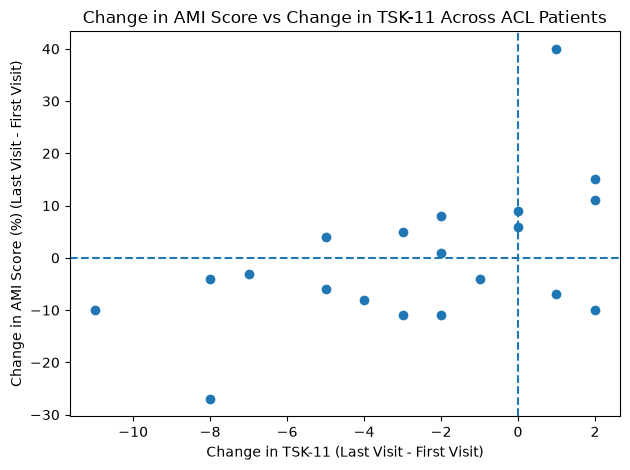

In [74]:
plt.scatter(
    change_df["tsk_change"],
    change_df["ami_change"]
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Change in TSK-11 (Last Visit - First Visit)")
plt.ylabel("Change in AMI Score (%) (Last Visit - First Visit)")
plt.title("Change in AMI Score vs Change in TSK-11 Across ACL Patients")

plt.tight_layout()
plt.show()

## Change Analysis

Each point represents one ACL patient.

The x-axis shows the change in TSK-11 score between the first and last recorded visit.

The y-axis shows the change in AMI score between the first and last recorded visit.

Most patients demonstrated relatively small changes in both measures, although several patients exhibited substantial improvements in AMI score. Visual inspection suggests considerable variability in patient trajectories and limited evidence of a strong relationship between changes in TSK-11 and changes in AMI score.

In [75]:
change_df[["ami_change", "tsk_change"]].corr()

,ami_change,tsk_change
ami_change,1.000000,0.520431
tsk_change,0.520431,1.000000


## Longitudinal Dataset Summary

In [76]:
num_patients = acl_df["patient_id"].nunique()

visit_counts = acl_df["patient_id"].value_counts()

print("Patients:", num_patients)
print("Average Visits:", visit_counts.mean())
print("Maximum Visits:", visit_counts.max())
print("Minimum Visits:", visit_counts.min())

Patients: 98
Average Visits: 4.23469387755102
Maximum Visits: 12
Minimum Visits: 1


## Longitudinal Findings

This notebook examined changes in AMI score and TSK-11 across repeated ACL assessments.

Key observations:

- Individual patient trajectories showed substantial variability.
- Some patients demonstrated large improvements in AMI score over time.
- Changes in TSK-11 were inconsistent across patients.
- Visual inspection suggested no strong relationship between changes in TSK-11 and changes in AMI score.
- Further statistical analysis was performed using change scores across patients.